# Analisis Kinerja Arsitektur Multi-Vector dan Zero-Retraining pada Sistem Presensi Real-Time Menggunakan Pipeline MTCNN-FaceNet

**Notebook Eksperimen — Metodologi Penelitian Ilmiah**

---

### Tentang Notebook Ini

Notebook ini mengimplementasikan **4 tahap metodologi penelitian**:

| Fase | Tahapan | Deskripsi |
|------|---------|-----------|
| **A** | Akuisisi Data & Skenario Uji | Capture wajah dengan variasi pose terukur (yaw, pitch) |
| **B** | Prapemrosesan Spasial | Deteksi wajah + landmark alignment menggunakan MTCNN |
| **C** | Ekstraksi Fitur & Proyeksi Ruang Metrik | Konversi citra ke vektor 512-d menggunakan FaceNet |
| **D** | Evaluasi Komparasi Vektor & Uji Ketahanan | Cosine Similarity, Confusion Matrix, Threshold Analysis, Latency |

**Target Publikasi:** Jurnal Ilmiah bidang Computer Science / Information Systems (SINTA 2-4)


---
## Teori Dasar: Pipeline Pengenalan Wajah

1. **Face Detection & Alignment** — Mendeteksi lokasi wajah dan menormalkan geometri
2. **Feature Extraction** — Mengekstrak representasi numerik (embedding) dari wajah
3. **Face Matching** — Membandingkan embedding menggunakan metrik jarak

Arsitektur **Zero-Retraining**: tidak perlu fine-tuning saat ada data baru.

```
[Input] → [MTCNN] → [FaceNet] → [512-d Vector] → [Cosine Similarity] → [Match/No-Match]
```


---
## Setup Environment & Import Library


In [5]:
import os, sys, time, json, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import torch
import cv2
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import precision_recall_curve, f1_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('All libraries imported.')


All libraries imported.


In [6]:
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR / 'data'
DATA_DIR.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

POSE_CONFIG = [
    {'name': 'depan',    'yaw': 0,   'pitch': 0,  'desc': 'Frontal (0 deg) — Anchor'},
    {'name': 'kanan_15', 'yaw': 15,  'pitch': 0,  'desc': 'Yaw +15 deg'},
    {'name': 'kanan_30', 'yaw': 30,  'pitch': 0,  'desc': 'Yaw +30 deg'},
    {'name': 'kanan_45', 'yaw': 45,  'pitch': 0,  'desc': 'Yaw +45 deg'},
    {'name': 'kiri_15',  'yaw': -15, 'pitch': 0,  'desc': 'Yaw -15 deg'},
    {'name': 'kiri_30',  'yaw': -30, 'pitch': 0,  'desc': 'Yaw -30 deg'},
    {'name': 'kiri_45',  'yaw': -45, 'pitch': 0,  'desc': 'Yaw -45 deg'},
    {'name': 'bawah_30', 'yaw': 0,   'pitch': 30, 'desc': 'Pitch +30 deg'},
]
FRAMES_PER_POSE = 5
ANCHOR_FRAMES = 3


Device: cpu


---
# FASE A: AKUISISI DATA & SKENARIO UJI

## Desain Eksperimen

Variabel bebas: sudut rotasi kepala pada sumbu Yaw dan Pitch.
Variabel terikat: Cosine Similarity dan akurasi klasifikasi.

| Kategori | Frame | Tujuan |
|----------|-------|--------|
| Anchor (depan 0 deg) | 3 | Referensi biometrik |
| Test Yaw +-15, +-30, +-45 deg | 5 each | Ketahanan rotasi horizontal |
| Test Pitch 30 deg | 5 | Ketahanan rotasi vertikal |

```
notebook/data/{nama_subjek}/
  anchor/  depan/  kanan_15/  kanan_30/  kanan_45/  kiri_15/  kiri_30/  kiri_45/  bawah_30/
```


In [7]:
import threading
import time
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

class WebcamAcquisitor:
    """
    Interactive webcam capture using ipywidgets.
    Fully event-driven — no blocking loops. Callbacks only.
    """
    def __init__(self, cam_id=0):
        self.cap = cv2.VideoCapture(cam_id)
        self.cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        self.cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        if not self.cap.isOpened():
            raise RuntimeError('Webcam tidak dapat diakses. Periksa koneksi kamera.')

        self.running = True
        self.frame_pil = None
        self.frame_count = 0

        # State per pose
        self.pose_configs = []
        self.current_pose_idx = 0
        self.subject_dir = None

        # UI widgets
        self.img = widgets.Image(format='jpg', width=640, height=480)
        self.label = widgets.HTML(value='<h3>⏳ Menyiapkan kamera...</h3>')
        self.info = widgets.HTML(value='')
        self.progress = widgets.IntProgress(value=0, min=0, max=1,
                                            layout=widgets.Layout(width='400px'))
        self.btn_capture = widgets.Button(
            description='📸 Capture',
            layout=widgets.Layout(width='160px'),
            button_style='success')
        self.btn_next = widgets.Button(
            description='⏭ Next Pose',
            layout=widgets.Layout(width='160px'),
            button_style='warning')
        self.btn_stop = widgets.Button(
            description='⏹ Stop',
            layout=widgets.Layout(width='100px'),
            button_style='danger')
        self.status = widgets.HTML(value='')
        self.done_label = widgets.HTML(value='')

        self.btn_capture.on_click(lambda b: self._on_capture())
        self.btn_next.on_click(lambda b: self._on_next())
        self.btn_stop.on_click(lambda b: self._on_stop())

        # Build UI
        display(widgets.VBox([
            self.label,
            self.info,
            self.img,
            self.progress,
            widgets.HBox([self.btn_capture, self.btn_next, self.btn_stop]),
            self.status,
            self.done_label
        ]))

        # Start webcam thread
        self.thread = threading.Thread(target=self._update_loop, daemon=True)
        self.thread.start()

    def _update_loop(self):
        while self.running:
            ret, frame_bgr = self.cap.read()
            if ret:
                try:
                    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
                    self.frame_pil = Image.fromarray(frame_rgb)
                    _, buffer = cv2.imencode('.jpg', frame_bgr, [int(cv2.IMWRITE_JPEG_QUALITY), 70])
                    self.img.value = buffer.tobytes()
                except:
                    pass
            time.sleep(0.03)

    def _show_current_pose(self):
        if self.current_pose_idx >= len(self.pose_configs):
            self._finish()
            return
        pose = self.pose_configs[self.current_pose_idx]
        self.cur_name = 'anchor' if pose['name'] == 'depan' else pose['name']
        self.cur_target = ANCHOR_FRAMES if pose['name'] == 'depan' else FRAMES_PER_POSE
        self.cur_captured = 0
        self.cur_dir = self.subject_dir / self.cur_name
        self.cur_dir.mkdir(parents=True, exist_ok=True)

        self.label.value = f'<h2>Pose: <b>{self.cur_name.upper()}</b></h2>'
        self.info.value = f'<b>Deskripsi:</b> {pose["desc"]} | Target: {self.cur_target} frame'
        self.progress.max = self.cur_target
        self.progress.value = 0
        self.progress.description = 'Frame:'
        self.status.value = '<i>Klik <b>📸 Capture</b> untuk mengambil frame. Klik <b>⏭ Next Pose</b> untuk lewati.</i>'
        self.btn_capture.disabled = False
        self.btn_next.disabled = False
        self.done_label.value = ''

    def _on_capture(self):
        """Save current frame to disk and increment counter."""
        if self.frame_pil is not None:
            self.cur_captured += 1
            fname = self.cur_dir / f'{self.cur_name}_{self.cur_captured:02d}.jpg'
            self.frame_pil.save(str(fname))
            self.progress.value = self.cur_captured
            self.status.value = f'<b>✔ Tersimpan:</b> {fname.name} ({self.cur_captured}/{self.cur_target})'
            if self.cur_captured >= self.cur_target:
                self.status.value += '<br><b style="color:green">✓ Pose selesai! Klik Next Pose atau lanjut capture.</b>'

    def _on_next(self):
        """Move to the next pose."""
        captured = getattr(self, 'cur_captured', 0)
        print(f'  Pose {self.cur_name}: {captured} frame tersimpan')
        self.current_pose_idx += 1
        self._show_current_pose()

    def _on_stop(self):
        """Emergency stop."""
        print('  ⏹ Dihentikan oleh user.')
        self.current_pose_idx = len(self.pose_configs)  # force finish
        self._finish()

    def _finish(self):
        self.running = False
        self.btn_capture.disabled = True
        self.btn_next.disabled = True
        self.btn_stop.disabled = True
        self.label.value = '<h2 style="color:green">✔ AKUISISI SELESAI</h2>'
        self.img.value = b''
        self.status.value = ''
        self.done_label.value = '<b style="color:green;font-size:14px">Kamera telah ditutup. Lanjut ke Fase B.</b>'
        time.sleep(0.3)
        self.cap.release()

    def run(self, subject_dir):
        """Start acquisition for all poses."""
        self.subject_dir = subject_dir
        self.pose_configs = POSE_CONFIG
        self.current_pose_idx = 0
        self._show_current_pose()

print('✅ WebcamAcquisitor siap.')


✅ WebcamAcquisitor siap.


In [8]:
# =====================================================================
# AKUISISI DATA — INTERAKTIF (ipywidgets)
# =====================================================================
# Masukkan nama subjek (akan dibuat folder dataset)
subject_name = input('Masukkan NAMA subjek: ').strip().replace(' ', '_')
if not subject_name:
    subject_name = f'subjek_{datetime.now():%Y%m%d_%H%M%S}'
subject_dir = DATA_DIR / subject_name
subject_dir.mkdir(exist_ok=True)
print(f'\n📁 Dataset: {subject_dir}')
print('\nPetunjuk:')
print('  1. 8 pose akan muncul satu per satu:')
for p in POSE_CONFIG:
    name = 'anchor' if p['name'] == 'depan' else p['name']
    target = ANCHOR_FRAMES if p['name'] == 'depan' else FRAMES_PER_POSE
    print(f'     • {name:12s} → {target} frame')
print('  2. Klik "📸 Capture" untuk ambil frame')
print('  3. Klik "⏭ Next Pose" untuk lanjut ke pose berikut\n')

cam = WebcamAcquisitor()
cam.run(subject_dir)
print('\nCell selesai. UI interaktif di atas siap digunakan.')



📁 Dataset: c:\Users\ihram\Documents\Iamfolder\project\Apps Full Stack\PresensiComputerVision\notebook\data\nabila

Petunjuk:
  1. 8 pose akan muncul satu per satu:
     • anchor       → 3 frame
     • kanan_15     → 5 frame
     • kanan_30     → 5 frame
     • kanan_45     → 5 frame
     • kiri_15      → 5 frame
     • kiri_30      → 5 frame
     • kiri_45      → 5 frame
     • bawah_30     → 5 frame
  2. Klik "📸 Capture" untuk ambil frame
  3. Klik "⏭ Next Pose" untuk lanjut ke pose berikut




Cell selesai. UI interaktif di atas siap digunakan.


In [9]:
subject_dirs = [d for d in DATA_DIR.iterdir() if d.is_dir()]
print(f'Subjek: {len(subject_dirs)}')
for s in subject_dirs:
    print(f'\n{s.name}:')
    for p in sorted(s.iterdir()):
        if p.is_dir():
            print(f'  {p.name}/ -> {len(list(p.glob("*.jpg")))} frame')


Subjek: 3

iank:
  anchor/ -> 3 frame
  bawah_30/ -> 5 frame
  kanan_15/ -> 5 frame
  kanan_45/ -> 5 frame
  kiri_15/ -> 5 frame
  kiri_30/ -> 5 frame

nabila:
  anchor/ -> 0 frame

subjek_20260611_133423:


---
# FASE B: PRAPEMROSESAN SPASIAL (MTCNN)

## Multi-task Cascaded Convolutional Networks (MTCNN)

Zhang et al. (2016) — 3 jaringan CNN bertingkat:

```
P-Net → Regional Proposal → R-Net → Refinement → O-Net → BBox + 5 Landmarks
```

**5 Landmarks:** Mata kiri, mata kanan, hidung, mulut kiri, mulut kanan.

FaceNet membutuhkan input wajah yang sudah **dialign** (tegak lurus) dan **tercrop** (160x160).
MTCNN menangani kedua hal ini sekaligus.


In [10]:
print('Loading MTCNN...')
mtcnn = MTCNN(image_size=160, margin=0, min_face_size=20,
              thresholds=[0.6, 0.7, 0.7], factor=0.709,
              post_process=True, device=DEVICE, keep_all=False)
mtcnn_vis = MTCNN(image_size=160, margin=0, min_face_size=20,
                  thresholds=[0.6, 0.7, 0.7], factor=0.709,
                  post_process=True, device=DEVICE, keep_all=True)
print(f'MTCNN loaded on {DEVICE}')


Loading MTCNN...
MTCNN loaded on cpu


### Visualisasi: Deteksi Wajah + 5 Landmarks

Subjek: iank


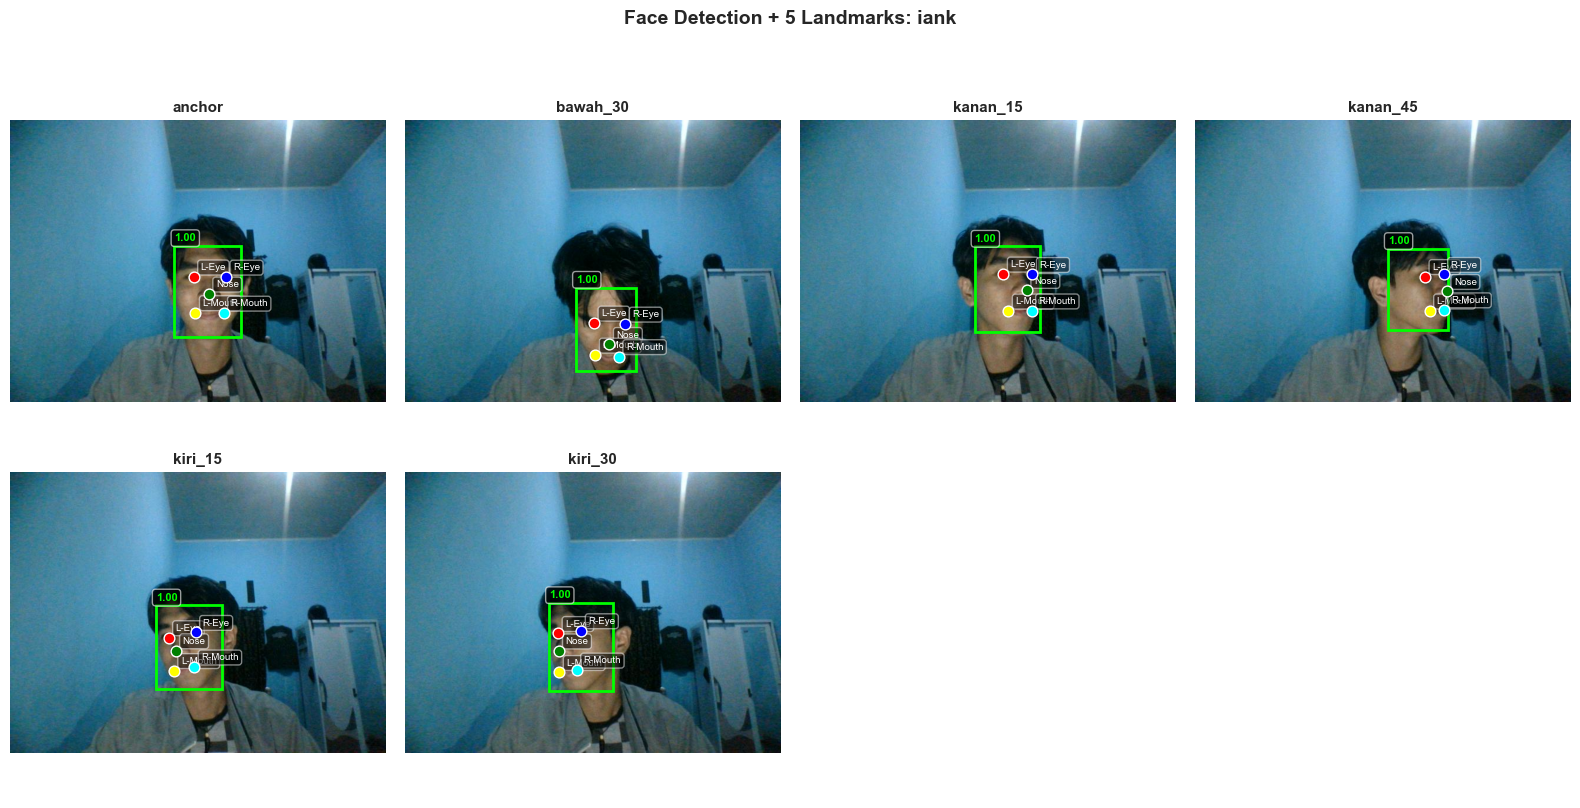

Saved: c:\Users\ihram\Documents\Iamfolder\project\Apps Full Stack\PresensiComputerVision\notebook\data\deteksi_wajah.png


In [25]:
subject_dirs = [d for d in DATA_DIR.iterdir() if d.is_dir()]
if not subject_dirs:
    raise FileNotFoundError('Jalankan Fase A dulu (tidak ada dataset).')
subj_dir = subject_dirs[0]
print(f'Subjek: {subj_dir.name}')

sample_images = {}
for pose_dir in sorted(subj_dir.iterdir()):
    if pose_dir.is_dir():
        imgs = list(pose_dir.glob('*.jpg'))
        if imgs:
            sample_images[pose_dir.name] = Image.open(str(imgs[0]))

if len(sample_images) == 0:
    print('⚠ Tidak ada gambar di dataset. Capture data di Fase A terlebih dahulu.')
else:
    n_samples = len(sample_images)
    n_cols = 4
    n_rows = int(np.ceil(n_samples / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()

    for idx, (pose_name, pil_img) in enumerate(sample_images.items()):
        img_rgb = np.array(pil_img)
        boxes, probs, landmarks = mtcnn_vis.detect(pil_img, landmarks=True)
        ax = axes[idx]
        ax.imshow(img_rgb)
        if boxes is not None and len(boxes) > 0:
            for i, box in enumerate(boxes):
                x1, y1, x2, y2 = box.astype(int)
                ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                             linewidth=2, edgecolor='lime', facecolor='none'))
                ax.text(x1, y1-8, f'{probs[i]:.2f}', color='lime', fontsize=8,
                        fontweight='bold', bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))
            if landmarks is not None:
                lm = landmarks[0]
                colors = ['red', 'blue', 'green', 'yellow', 'cyan']
                labels = ['L-Eye', 'R-Eye', 'Nose', 'L-Mouth', 'R-Mouth']
                for i, (x, y) in enumerate(lm):
                    ax.scatter(x, y, c=colors[i], s=60, edgecolors='white', linewidth=1, zorder=5)
                    ax.annotate(labels[i], (x, y), textcoords='offset points',
                               xytext=(5, 5), fontsize=7, color='white',
                               bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
        ax.set_title(pose_name, fontsize=11, fontweight='bold')
        ax.axis('off')

    for idx in range(n_samples, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Face Detection + 5 Landmarks: {subj_dir.name}', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'deteksi_wajah.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {DATA_DIR / "deteksi_wajah.png"}')


### Visualisasi: Face Alignment Before vs After

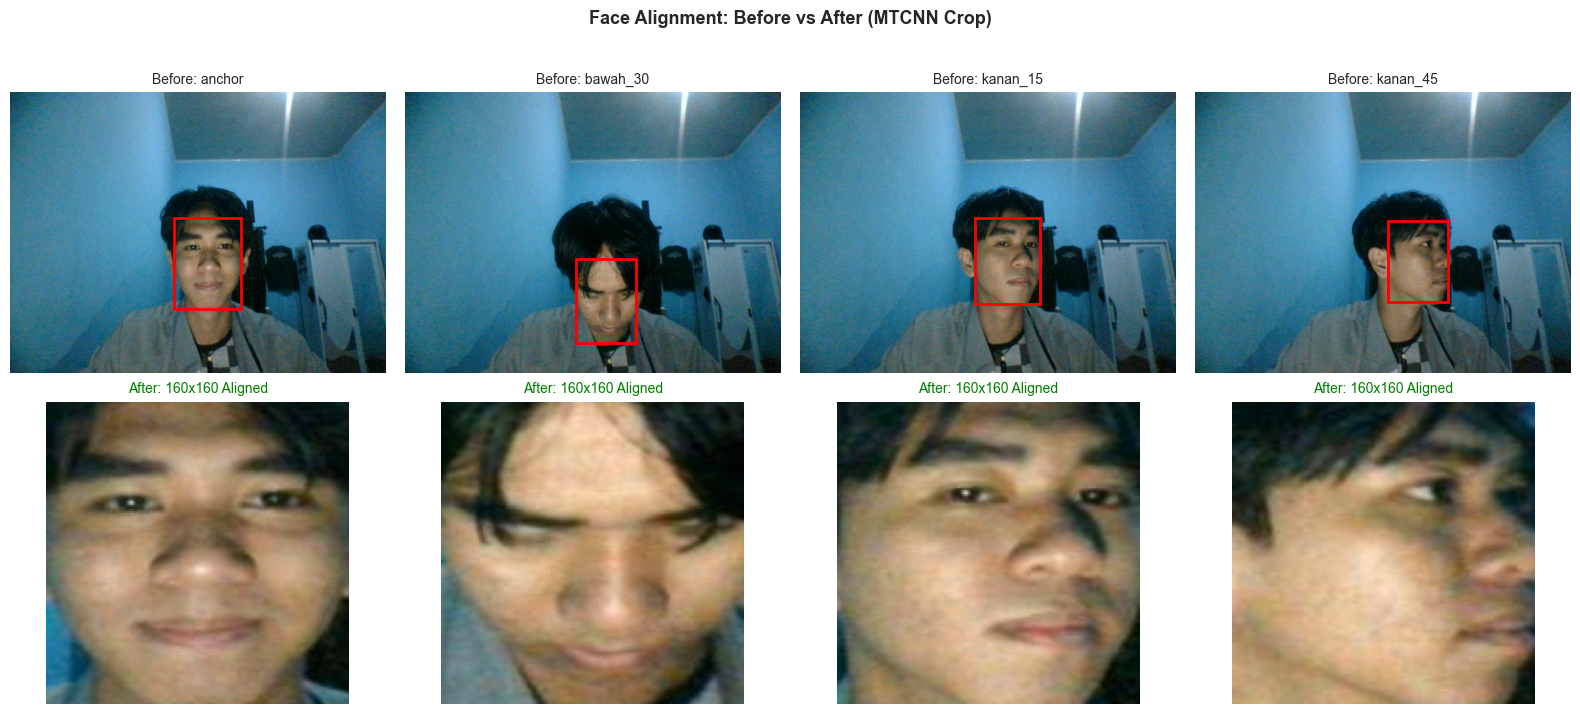

In [12]:
if len(sample_images) == 0:
    print('⚠ Tidak ada gambar. Capture data di Fase A terlebih dahulu.')
else:
    n_display = min(len(sample_images), 4)
    fig, axes = plt.subplots(2, n_display, figsize=(16, 7))
    for idx, (pose_name, pil_img) in enumerate(sample_images.items()):
        if idx >= n_display:
            break
        img_rgb = np.array(pil_img)
        boxes, _ = mtcnn_vis.detect(pil_img, landmarks=False)
        ax0 = axes[0, idx]
        ax0.imshow(img_rgb)
        if boxes is not None:
            x1, y1, x2, y2 = boxes[0].astype(int)
            ax0.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none'))
        ax0.set_title(f'Before: {pose_name}', fontsize=10)
        ax0.axis('off')
        face_tensor = mtcnn(pil_img)
        ax1 = axes[1, idx]
        if face_tensor is not None:
            face_img = face_tensor.cpu().permute(1, 2, 0).numpy()
            face_img = (face_img - face_img.min()) / (face_img.max() - face_img.min() + 1e-8)
            ax1.imshow(face_img)
            ax1.set_title('After: 160x160 Aligned', fontsize=10, color='green')
        else:
            ax1.text(0.5, 0.5, 'No Face', ha='center', va='center')
            ax1.set_title('Failed', color='red')
        ax1.axis('off')

    plt.suptitle('Face Alignment: Before vs After (MTCNN Crop)', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'face_alignment.png', dpi=150, bbox_inches='tight')
    plt.show()


### Analisis: Tingkat Deteksi per Pose

Detection rate per pose:
  anchor      : 3/3 (100.0%)
  bawah_30    : 5/5 (100.0%)
  kanan_15    : 5/5 (100.0%)
  kanan_45    : 5/5 (100.0%)
  kiri_15     : 5/5 (100.0%)
  kiri_30     : 5/5 (100.0%)


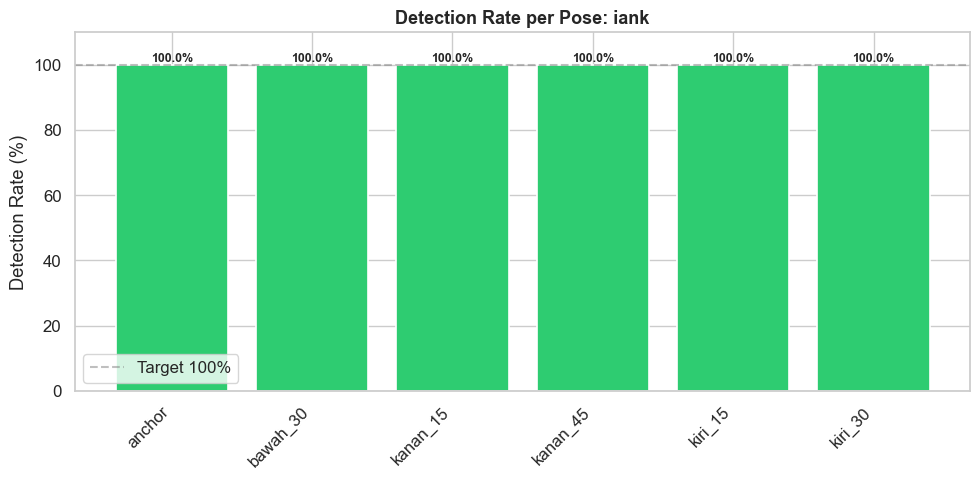

In [13]:
print('Detection rate per pose:')
det_stats = []
has_any_images = False
for pose_dir in sorted(subj_dir.iterdir()):
    if not pose_dir.is_dir():
        continue
    imgs = sorted(pose_dir.glob('*.jpg'))
    total = len(imgs)
    if total > 0:
        has_any_images = True
    detected = sum(1 for p in imgs if mtcnn(Image.open(str(p))) is not None)
    rate = detected / total * 100 if total > 0 else 0
    det_stats.append({'pose': pose_dir.name, 'total': total, 'detected': detected, 'rate': rate})
    print(f'  {pose_dir.name:12s}: {detected}/{total} ({rate:.1f}%)')

if not has_any_images:
    print('⚠ Tidak ada gambar untuk dianalisis.')
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    poses = [s['pose'] for s in det_stats]
    rates = [s['rate'] for s in det_stats]
    colors = ['#2ecc71' if r==100 else '#f39c12' if r>=70 else '#e74c3c' for r in rates]
    bars = ax.bar(poses, rates, color=colors, edgecolor='white', linewidth=1.2)
    ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Target 100%')
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{rate:.1f}%',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_ylabel('Detection Rate (%)')
    ax.set_title(f'Detection Rate per Pose: {subj_dir.name}', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110); ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'deteksi_rate.png', dpi=150, bbox_inches='tight')
    plt.show()


---
# FASE C: EKSTRAKSI FITUR & PROYEKSI RUANG METRIK

## FaceNet: Unified Embedding for Face Recognition

Schroff et al. (2015) — Memproyeksikan wajah ke ruang Euclidean 512 dimensi.

**Triplet Loss:**
$$L = sum_i [ ||f(x_i^a) - f(x_i^p)||^2 - ||f(x_i^a) - f(x_i^n)||^2 + alpha ]_+$$

- $x^a$ = Anchor, $x^p$ = Positive (wajah sama), $x^n$ = Negative (wajah beda)
- $f(x)$ = embedding vector, $alpha$ = margin

Model: **InceptionResNetV1** pretrained pada **VGGFace2** (3.3M gambar, 9.131 identitas).

```
160x160x3 → Inception-ResNet → Global Avg Pool → L2 Norm → [512-d Vector]
```


In [14]:
print('Loading FaceNet (InceptionResNetV1 vggface2)...')
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(DEVICE)
print(f'FaceNet loaded on {DEVICE} | Output: 512-d')


Loading FaceNet (InceptionResNetV1 vggface2)...
FaceNet loaded on cpu | Output: 512-d


In [15]:
def extract_embedding(pil_img):
    face_tensor = mtcnn(pil_img)
    if face_tensor is None:
        return None
    face_tensor = face_tensor.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = resnet(face_tensor).cpu().numpy().flatten()
    return emb

def extract_all_embeddings(subject_dir):
    result = {}
    for pose_dir in sorted(subject_dir.iterdir()):
        if not pose_dir.is_dir():
            continue
        embs = []
        for img_path in sorted(pose_dir.glob('*.jpg')):
            emb = extract_embedding(Image.open(str(img_path)))
            if emb is not None:
                embs.append(emb)
        if embs:
            result[pose_dir.name] = np.array(embs)
    return result

print('Extracting embeddings for all subjects...')
all_embeddings = {}
total_embs = 0
for subj in subject_dirs:
    print(f'  {subj.name}...', end=' ', flush=True)
    embs = extract_all_embeddings(subj)
    all_embeddings[subj.name] = embs
    n_total = sum(v.shape[0] for v in embs.values())
    total_embs += n_total
    print(f'{n_total} embeddings')
print(f'Done. Total embeddings: {total_embs}')
if total_embs == 0:
    print('⚠ Tidak ada embedding yang dihasilkan. Capture data di Fase A terlebih dahulu.')


Extracting embeddings for all subjects...
  iank... 

28 embeddings
  nabila... 2 embeddings
  subjek_20260611_133423... 0 embeddings
Done. Total embeddings: 30


### Sample Embedding Vector (10 dimensi pertama)

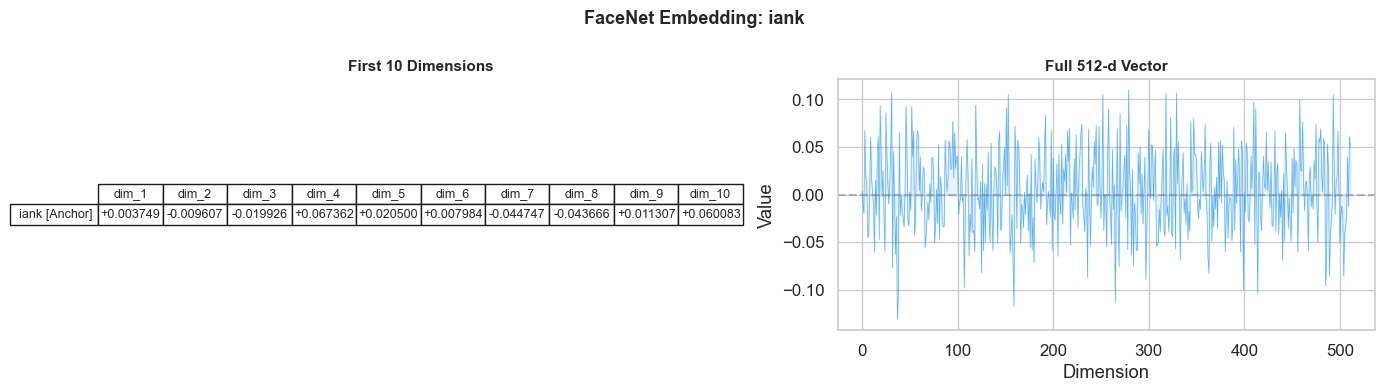

L2 Norm: 1.0000 (should be ~1.0)


In [16]:
if len(all_embeddings) == 0 or all(len(v)==0 for v in all_embeddings.values()):
    print('⚠ Tidak ada embedding. Capture data di Fase A terlebih dahulu.')
else:
    first_subj = list(all_embeddings.keys())[0]
    anchor = all_embeddings[first_subj].get('anchor')
    if anchor is not None and len(anchor) > 0:
        sv = anchor[0]
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
        cols = [f'dim_{i+1}' for i in range(10)]
        rows = [f'{first_subj} [Anchor]']
        data = [[f'{sv[i]:+.6f}' for i in range(10)]]
        a1.axis('tight'); a1.axis('off')
        tbl = a1.table(cellText=data, rowLabels=rows, colLabels=cols, loc='center', cellLoc='center')
        tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 1.5)
        a1.set_title('First 10 Dimensions', fontsize=11, fontweight='bold')
        a2.plot(sv, alpha=0.7, linewidth=0.5, color='#2196F3')
        a2.fill_between(range(512), sv, alpha=0.1, color='#2196F3')
        a2.set_xlabel('Dimension'); a2.set_ylabel('Value')
        a2.set_title('Full 512-d Vector', fontsize=11, fontweight='bold')
        a2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        plt.suptitle(f'FaceNet Embedding: {first_subj}', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(DATA_DIR / 'sample_embedding.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'L2 Norm: {np.linalg.norm(sv):.4f} (should be ~1.0)')


### PCA: Proyeksi Embedding ke 2D

Explained variance: PC1=0.324, PC2=0.174, Total=0.498


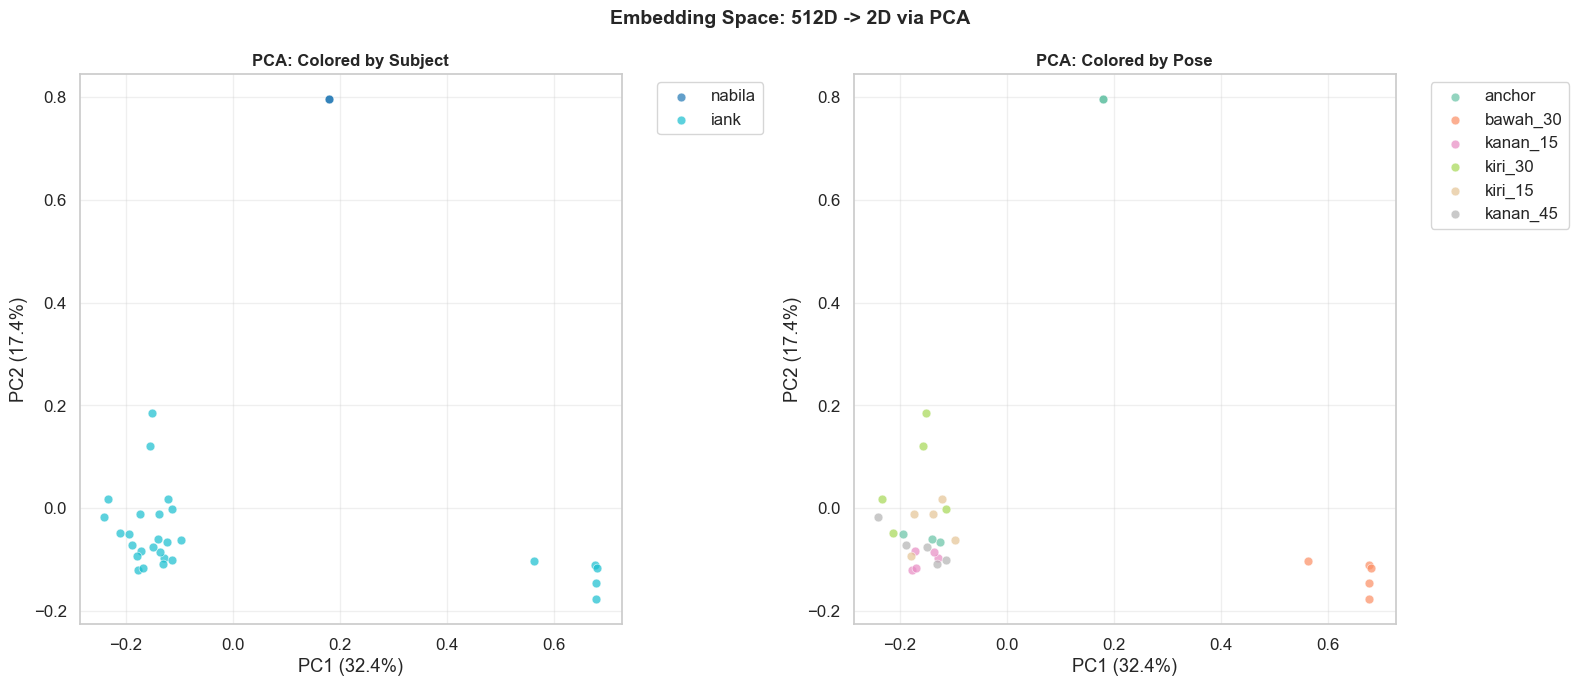

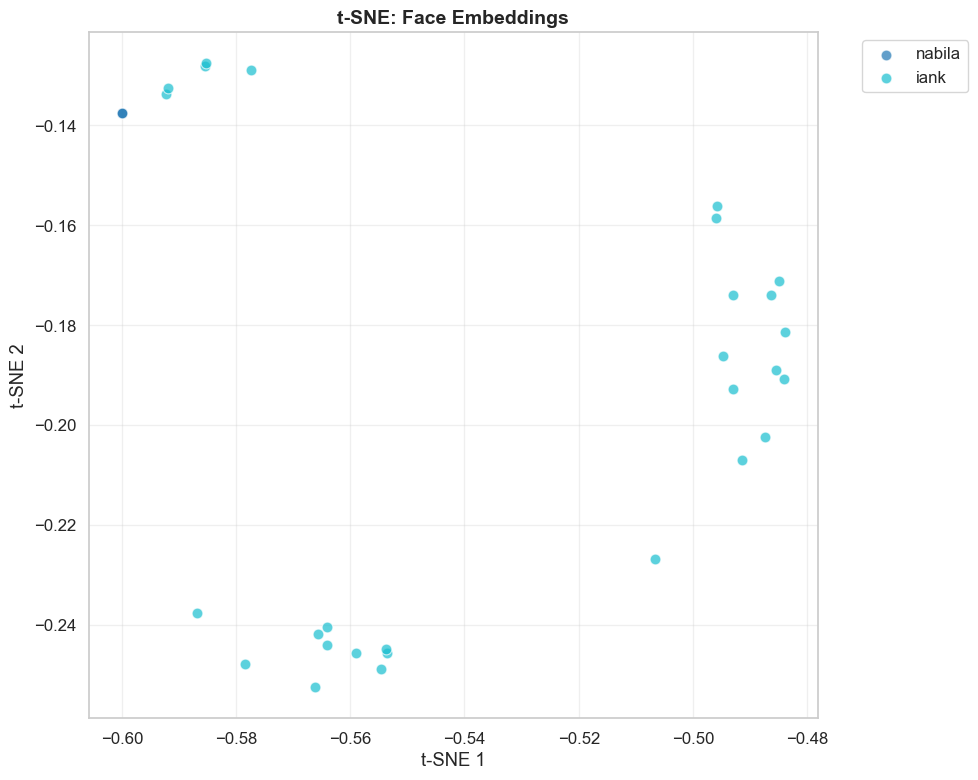

In [17]:
all_vecs, all_labels, all_poses = [], [], []
for sn, poses in all_embeddings.items():
    for pn, embs in poses.items():
        for v in embs:
            all_vecs.append(v); all_labels.append(sn); all_poses.append(pn)
all_vecs = np.array(all_vecs)

if len(all_vecs) == 0:
    print('⚠ Tidak ada embedding untuk divisualisasikan.')
else:
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(all_vecs)
    ev = pca.explained_variance_ratio_
    print(f'Explained variance: PC1={ev[0]:.3f}, PC2={ev[1]:.3f}, Total={ev.sum():.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    unique_subj = list(set(all_labels))
    unique_pose = list(set(all_poses))
    colors_subj = plt.cm.tab10(np.linspace(0, 1, len(unique_subj)))
    colors_pose = plt.cm.Set2(np.linspace(0, 1, len(unique_pose)))

    for i, s in enumerate(unique_subj):
        mask = [l==s for l in all_labels]
        axes[0].scatter(coords[mask,0], coords[mask,1], c=[colors_subj[i]], label=s, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
    axes[0].set_xlabel(f'PC1 ({ev[0]:.1%})'); axes[0].set_ylabel(f'PC2 ({ev[1]:.1%})')
    axes[0].set_title('PCA: Colored by Subject', fontsize=12, fontweight='bold')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left'); axes[0].grid(True, alpha=0.3)

    for i, p in enumerate(unique_pose):
        mask = [pp==p for pp in all_poses]
        axes[1].scatter(coords[mask,0], coords[mask,1], c=[colors_pose[i]], label=p, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
    axes[1].set_xlabel(f'PC1 ({ev[0]:.1%})'); axes[1].set_ylabel(f'PC2 ({ev[1]:.1%})')
    axes[1].set_title('PCA: Colored by Pose', fontsize=12, fontweight='bold')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left'); axes[1].grid(True, alpha=0.3)

    plt.suptitle('Embedding Space: 512D -> 2D via PCA', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'pca_space.png', dpi=150, bbox_inches='tight')
    plt.show()

    # t-SNE only runs if PCA succeeded
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_vecs)-1))
    tc = tsne.fit_transform(all_vecs)
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, s in enumerate(unique_subj):
        mask = [l==s for l in all_labels]
        ax.scatter(tc[mask,0], tc[mask,1], c=[colors_subj[i]], label=s, alpha=0.7, s=60, edgecolors='white', linewidth=0.8)
    ax.set_title('t-SNE: Face Embeddings', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'tsne_space.png', dpi=150, bbox_inches='tight')
    plt.show()


---
# FASE D: EVALUASI KOMPARASI VEKTOR & UJI KETAHANAN

## Cosine Similarity

$$similarity(A,B) = cos(theta) = (A cdot B) / (||A|| ||B||) = sum_i A_i B_i / sqrt(sum_i A_i^2) sqrt(sum_i B_i^2)$$

Dengan L2 norm, $||A|| = ||B|| = 1$, maka $similarity(A,B) = A cdot B$.

Nilai: $[-1, +1]$, di mana +1 = identik.

## Threshold Analysis

Threshold (tau) menentukan batas keputusan:
- tau tinggi -> aman, banyak False Negative
- tau rendah -> mudah, banyak False Positive


In [18]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

def compute_similarity(embeddings_dict):
    anchor = embeddings_dict.get('anchor', embeddings_dict.get('depan'))
    if anchor is None:
        return None
    anchor_vec = np.mean(anchor, axis=0)
    anchor_vec /= np.linalg.norm(anchor_vec)
    results = {}
    for pose_name, embs in embeddings_dict.items():
        scores = [cosine_similarity(anchor_vec, v/np.linalg.norm(v)) for v in embs]
        results[pose_name] = {'mean': np.mean(scores), 'std': np.std(scores),
                              'min': np.min(scores), 'max': np.max(scores), 'all': scores}
    return results

if len(all_embeddings) == 0:
    print('⚠ Tidak ada embedding. Capture data di Fase A terlebih dahulu.')
    sim = None
else:
    first_subj = list(all_embeddings.keys())[0]
    sim = compute_similarity(all_embeddings[first_subj])
    if sim:
        print(f'Subjek: {first_subj}')
        print(f'{"Pose":15s} {"Mean":>8s} {"Std":>8s} {"Min":>8s} {"Max":>8s}')
        print('-'*50)
        for pn, m in sorted(sim.items()):
            print(f'{pn:15s} {m["mean"]:8.4f} {m["std"]:8.4f} {m["min"]:8.4f} {m["max"]:8.4f}')


Subjek: iank
Pose                Mean      Std      Min      Max
--------------------------------------------------
anchor            0.9874   0.0054   0.9799   0.9920
bawah_30          0.5827   0.0396   0.5473   0.6581
kanan_15          0.8612   0.0132   0.8449   0.8784
kanan_45          0.7353   0.0693   0.6581   0.8313
kiri_15           0.8973   0.0104   0.8821   0.9136
kiri_30           0.8284   0.0201   0.7918   0.8483


### Distribusi Cosine Similarity per Pose

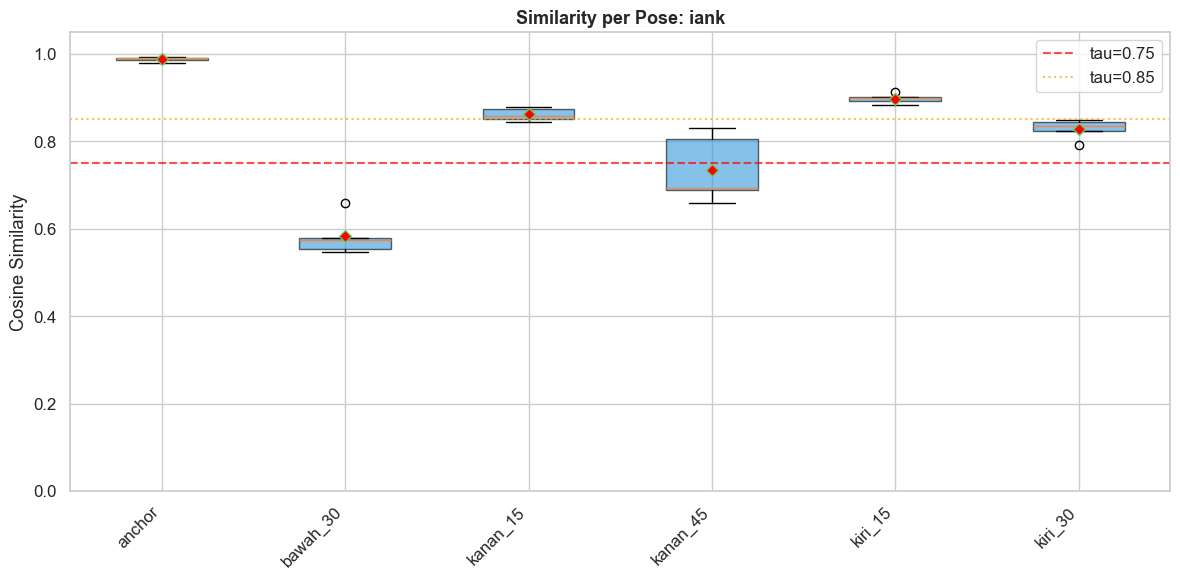

In [19]:
if sim:
    fig, ax = plt.subplots(figsize=(12, 6))
    pnames, scrs = [], []
    for pn, m in sorted(sim.items()):
        pnames.append(pn); scrs.append(m['all'])
    bp = ax.boxplot(scrs, labels=pnames, patch_artist=True, showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
    colors_box = ['#2ecc71' if p=='anchor' else '#3498db' for p in pnames]
    for patch, c in zip(bp['boxes'], colors_box):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.axhline(y=0.75, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='tau=0.75')
    ax.axhline(y=0.85, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='tau=0.85')
    ax.set_ylabel('Cosine Similarity'); ax.set_title(f'Similarity per Pose: {first_subj}', fontsize=13, fontweight='bold')
    ax.legend(); ax.set_ylim(0, 1.05)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'similarity_dist.png', dpi=150, bbox_inches='tight')
    plt.show()


### Threshold Analysis: F1-Score Optimization

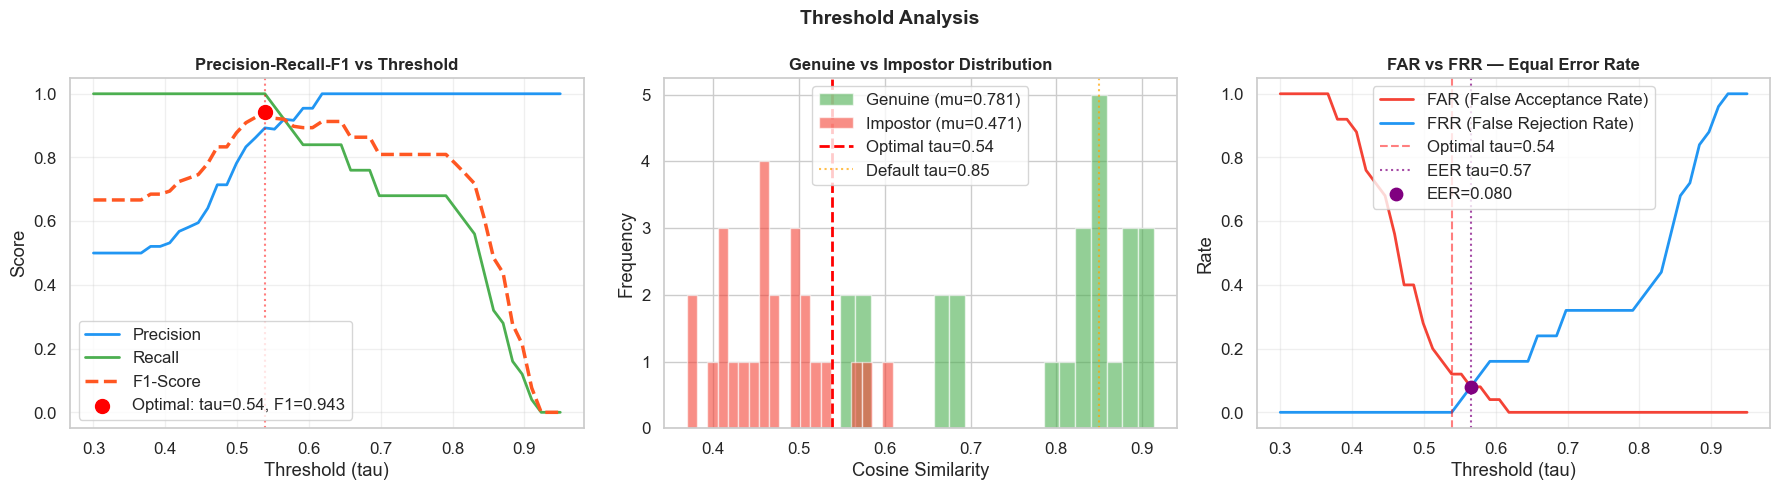


Optimal threshold: tau=0.5388
Best F1-Score: 0.9434
Precision at tau=0.54: 0.8929
Recall at tau=0.54: 1.0000
FAR at tau=0.54: 0.1200 (12.00%)
FRR at tau=0.54: 0.0000 (0.00%)

Equal Error Rate (EER): 0.0800 (8.00%) at tau=0.5653


In [20]:
if len(all_embeddings) >= 2:
    genuine, impostor = [], []
    subj_names = list(all_embeddings.keys())
    for i, si in enumerate(subj_names):
        ai = all_embeddings[si].get('anchor', all_embeddings[si].get('depan'))
        if ai is None: continue
        av = np.mean(ai, axis=0); av /= np.linalg.norm(av)
        for j, sj in enumerate(subj_names):
            test_embs = []
            for pn, embs in all_embeddings[sj].items():
                if pn not in ('anchor', 'depan'): test_embs.extend(embs)
            if not test_embs: continue
            for v in test_embs:
                s = cosine_similarity(av, v/np.linalg.norm(v))
                if i == j: genuine.append(s)
                else: impostor.append(s)

    genuine = np.array(genuine); impostor = np.array(impostor)
    y_true = np.concatenate([np.ones(len(genuine)), np.zeros(len(impostor))])
    y_scores = np.concatenate([genuine, impostor])

    thresholds = np.linspace(0.3, 0.95, 50)
    precisions, recalls, f1s = [], [], []
    fars, frrs = [], []
    for tau in thresholds:
        yp = (y_scores >= tau).astype(int)
        tp = np.sum((yp==1) & (y_true==1))
        fp = np.sum((yp==1) & (y_true==0))
        fn = np.sum((yp==0) & (y_true==1))
        tn = np.sum((yp==0) & (y_true==0))
        p = tp/(tp+fp) if (tp+fp)>0 else 1
        r = tp/(tp+fn) if (tp+fn)>0 else 1
        far = fp/(fp+tn) if (fp+tn)>0 else 0
        frr = fn/(fn+tp) if (fn+tp)>0 else 1
        f1s.append(2*p*r/(p+r) if (p+r)>0 else 0)
        precisions.append(p); recalls.append(r)
        fars.append(far); frrs.append(frr)

    best_idx = np.argmax(f1s)
    best_tau, best_f1 = thresholds[best_idx], f1s[best_idx]
    
    fars = np.array(fars); frrs = np.array(frrs)
    eer_idx = np.argmin(np.abs(fars - frrs))
    eer_tau = thresholds[eer_idx]
    eer = (fars[eer_idx] + frrs[eer_idx]) / 2

    fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(18, 5))
    a1.plot(thresholds, precisions, label='Precision', linewidth=2, color='#2196F3')
    a1.plot(thresholds, recalls, label='Recall', linewidth=2, color='#4CAF50')
    a1.plot(thresholds, f1s, label='F1-Score', linewidth=2.5, color='#FF5722', linestyle='--')
    a1.scatter(best_tau, best_f1, color='red', s=100, zorder=5, label=f'Optimal: tau={best_tau:.2f}, F1={best_f1:.3f}')
    a1.axvline(x=best_tau, color='red', linestyle=':', alpha=0.5)
    a1.set_xlabel('Threshold (tau)'); a1.set_ylabel('Score')
    a1.set_title('Precision-Recall-F1 vs Threshold', fontsize=12, fontweight='bold')
    a1.legend(); a1.grid(True, alpha=0.3)

    a2.hist(genuine, bins=20, alpha=0.6, label=f'Genuine (mu={np.mean(genuine):.3f})', color='#4CAF50', edgecolor='white')
    a2.hist(impostor, bins=20, alpha=0.6, label=f'Impostor (mu={np.mean(impostor):.3f})', color='#F44336', edgecolor='white')
    a2.axvline(x=best_tau, color='red', linestyle='--', linewidth=2, label=f'Optimal tau={best_tau:.2f}')
    a2.axvline(x=0.85, color='orange', linestyle=':', linewidth=1.5, label='Default tau=0.85', alpha=0.7)
    a2.set_xlabel('Cosine Similarity'); a2.set_ylabel('Frequency')
    a2.set_title('Genuine vs Impostor Distribution', fontsize=12, fontweight='bold')
    a2.legend()

    # Subplot 3: FAR vs FRR + EER
    a3.plot(thresholds, fars, label='FAR (False Acceptance Rate)', linewidth=2, color='#F44336')
    a3.plot(thresholds, frrs, label='FRR (False Rejection Rate)', linewidth=2, color='#2196F3')
    a3.axvline(x=best_tau, color='red', linestyle='--', alpha=0.5, label=f'Optimal tau={best_tau:.2f}')
    a3.axvline(x=eer_tau, color='purple', linestyle=':', alpha=0.7, label=f'EER tau={eer_tau:.2f}')
    a3.scatter(eer_tau, eer, color='purple', s=80, zorder=5, label=f'EER={eer:.3f}')
    a3.set_xlabel('Threshold (tau)')
    a3.set_ylabel('Rate')
    a3.set_title('FAR vs FRR — Equal Error Rate', fontsize=12, fontweight='bold')
    a3.legend(); a3.grid(True, alpha=0.3)

    plt.suptitle('Threshold Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'threshold_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nOptimal threshold: tau={best_tau:.4f}')
    print(f'Best F1-Score: {best_f1:.4f}')
    print(f'Precision at tau={best_tau:.2f}: {precisions[best_idx]:.4f}')
    print(f'Recall at tau={best_tau:.2f}: {recalls[best_idx]:.4f}')
    print(f'FAR at tau={best_tau:.2f}: {fars[best_idx]:.4f} ({fars[best_idx]*100:.2f}%)')
    print(f'FRR at tau={best_tau:.2f}: {frrs[best_idx]:.4f} ({frrs[best_idx]*100:.2f}%)')
    print(f'\nEqual Error Rate (EER): {eer:.4f} ({eer*100:.2f}%) at tau={eer_tau:.4f}')
else:
    print('Need >= 2 subjects for threshold analysis.')


---
# Fase Uji Coba Real-time: Evaluasi Langsung via Kamera

## Cara Kerja
1. **Isi nama subjek** (GT) di kolom teks — kosongkan jika orang asing
2. Klik **Capture & Test** untuk menangkap frame dan menguji
3. Sistem:
   - Deteksi wajah via MTCNN
   - Ekstrak embedding via FaceNet
   - Bandingkan dengan semua anchor tersimpan (cosine similarity)
   - Prediksi subjek dengan similarity tertinggi (jika ≥ τ)
4. Hasil ditampilkan di tabel + confusion matrix setelah **Finish & Evaluasi**

## Metrik
- **Accuracy** (TP + TN / total)
- **Precision, Recall, F1** per subjek
- **Confusion Matrix**
- **Macro Average**
- **FAR** (False Acceptance Rate): impostor (`<unknown>`) yang salah diterima
- **FRR** (False Rejection Rate): subjek dikenal yang salah ditolak


In [21]:
if len(all_embeddings) < 1:
    print('\u26a0 Tidak ada anchor. Capture data di Fase A terlebih dahulu.')
else:
    ref_names, ref_vecs = [], []
    for subj, poses in all_embeddings.items():
        anchor = poses.get('anchor', poses.get('depan'))
        if anchor is not None and len(anchor) > 0:
            av = np.mean(anchor, axis=0)
            av /= np.linalg.norm(av)
            ref_names.append(subj)
            ref_vecs.append(av)
    ref_vecs = np.array(ref_vecs)
    tau = best_tau if 'best_tau' in dir() else 0.85
    print(f'Anchor tersedia: {len(ref_names)} subjek, tau={tau:.4f}')
    print()

    class WebcamTester:
        def __init__(self):
            self.results = []
            self.device = DEVICE
            self.mtcnn = MTCNN(keep_all=False, device=self.device, select_largest=False)
            self.resnet = InceptionResnetV1(pretrained='vggface2').eval().to(self.device)
            self.gt_input = widgets.Text(placeholder='Kosongkan = <unknown>', description='GT:')
            self.cap_btn = widgets.Button(description='Capture & Test', button_style='primary')
            self.finish_btn = widgets.Button(description='Finish & Evaluasi', button_style='success')
            self.out = widgets.Output(layout=widgets.Layout(border='1px solid #ccc', min_height='100px'))
            self.progress = widgets.IntProgress(value=0, min=0, max=9999, description='Tes:')
            self.img_widget = widgets.Image(format='jpeg', width=320, height=240)
            self.table_out = widgets.Output(layout=widgets.Layout(max_height='250px', overflow_y='scroll'))
            self.cap = cv2.VideoCapture(0)
            self.running = False
            self.thread = None
            self.cap_btn.on_click(self._on_capture)
            self.finish_btn.on_click(self._on_finish)

        def start(self):
            if not self.cap.isOpened():
                print('\u26a0 Kamera tidak dapat dibuka.')
                return
            self.running = True
            self.thread = threading.Thread(target=self._loop, daemon=True)
            self.thread.start()
            display(widgets.VBox([
                widgets.HBox([self.gt_input, self.cap_btn, self.finish_btn]),
                self.progress,
                widgets.HBox([self.img_widget, self.out]),
                self.table_out,
            ]))

        def _loop(self):
            while self.running:
                ret, frame = self.cap.read()
                if ret:
                    _, buffer = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 65])
                    self.img_widget.value = buffer.tobytes()
                time.sleep(0.04)

        def _on_capture(self, b):
            ret, frame = self.cap.read()
            if not ret: return
            gt = self.gt_input.value.strip() or '<unknown>'
            pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            face = self.mtcnn(pil_img)
            if face is None:
                with self.out:
                    clear_output(wait=True)
                    print('\u26a0 No face detected')
                return
            with torch.no_grad():
                emb = self.resnet(face.unsqueeze(0).to(self.device)).cpu().numpy()[0]
            emb /= np.linalg.norm(emb)
            sims = np.dot(ref_vecs, emb)
            best_idx = np.argmax(sims)
            best_sim = sims[best_idx]
            best_name = ref_names[best_idx] if best_sim >= tau else '<unknown>'
            correct = (gt == best_name) or (gt == '<unknown>' and best_name == '<unknown>')
            self.results.append({'gt': gt, 'pred': best_name, 'sim': float(best_sim), 'correct': correct})
            self.progress.value = len(self.results)
            with self.out:
                clear_output(wait=True)
                top3 = np.argsort(sims)[-3:][::-1].tolist()
                top3_str = ' | '.join(f'{ref_names[i]}={sims[i]:.3f}' for i in top3)
                status = '\u2713' if correct else '\u2717'
                print(f'GT: {gt:15s} | Pred: {best_name:15s} | Sim: {best_sim:.4f} | {status}')
                print(f'Top-3: {top3_str}')
            self._update_table()

        def _update_table(self):
            with self.table_out:
                clear_output(wait=True)
                if not self.results: return
                print(f'{"No":>3s} {"GT":12s} {"Pred":12s} {"Sim":>7s} {"St":>3s}')
                print('-' * 40)
                start = max(0, len(self.results) - 20)
                for i in range(start, len(self.results)):
                    r = self.results[i]
                    st = '\u2713' if r['correct'] else '\u2717'
                    print('%3d %-12s %-12s %7.4f %3s' % (i+1, r['gt'], r['pred'], r['sim'], st))

        def _on_finish(self, b):
            self.running = False
            if self.thread: self.thread.join()
            self.cap.release()
            cv2.destroyAllWindows()
            with self.out:
                clear_output(wait=True)
                print('Selesai. Menampilkan hasil akhir...')
            self._show_metrics()

        def _show_metrics(self):
            if not self.results:
                print('Tidak ada data tes.')
                return
            n = len(self.results)
            correct = sum(1 for r in self.results if r['correct'])
            acc = correct / n * 100
            print(f'Total tes: {n}')
            print(f'Correct:  {correct}/{n}')
            print(f'Accuracy: {acc:.2f}%')
            print()
            all_labels = sorted(set(r['gt'] for r in self.results) | set(r['pred'] for r in self.results))
            n_labels = len(all_labels)
            label_idx = {l: i for i, l in enumerate(all_labels)}
            cm = np.zeros((n_labels, n_labels), dtype=int)
            for r in self.results:
                gt_i = label_idx[r['gt']]
                pred_i = label_idx.get(r['pred'], label_idx.get('<unknown>', 0))
                cm[gt_i, pred_i] += 1
            fig, ax = plt.subplots(figsize=(9, 7))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=all_labels, yticklabels=all_labels, ax=ax)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Ground Truth')
            ax.set_title(f'Confusion Matrix \u2014 Real-time Test (Acc={acc:.1f}%)', fontweight='bold')
            plt.tight_layout()
            plt.savefig(DATA_DIR / 'realtime_cm.png', dpi=150, bbox_inches='tight')
            plt.show()
            print(f'\n{"Label":12s} {"Prec":>7s} {"Rec":>7s} {"F1":>7s} {"N":>5s}')
            print('-' * 40)
            precs, recs, f1s = [], [], []
            for i, label in enumerate(all_labels):
                tp = cm[i, i]
                fp = cm[:, i].sum() - tp
                fn = cm[i, :].sum() - tp
                prec = tp / (tp + fp + 1e-8)
                rec = tp / (tp + fn + 1e-8)
                f1 = 2 * prec * rec / (prec + rec + 1e-8)
                precs.append(prec); recs.append(rec); f1s.append(f1)
                n_gt = cm[i, :].sum()
                print(f'{label:12s} {prec:7.3f} {rec:7.3f} {f1:7.3f} {n_gt:5d}')
            precs = np.array(precs); recs = np.array(recs); f1s = np.array(f1s)
            print(f'\nMacro Avg: Prec={precs.mean():.3f} Rec={recs.mean():.3f} F1={f1s.mean():.3f}')
            # FAR / FRR
            unknown_gt = [r for r in self.results if r['gt'] == '<unknown>']
            known_gt = [r for r in self.results if r['gt'] != '<unknown>']
            if unknown_gt:
                fa = sum(1 for r in unknown_gt if r['pred'] != '<unknown>')
                far = fa / len(unknown_gt)
            else:
                far = float('nan')
            if known_gt:
                fr = sum(1 for r in known_gt if r['pred'] != r['gt'])
                frr = fr / len(known_gt)
            else:
                frr = float('nan')
            print(f'\n--- Biometric Security Metrics ---')
            if not np.isnan(far):
                print(f'Impostor attempts (<unknown> GT): {len(unknown_gt)}')
                print(f'FAR (False Acceptance Rate): {far:.4f} ({far*100:.2f}%)')
            if not np.isnan(frr):
                print(f'Genuine attempts (known GT): {len(known_gt)}')
                print(f'FRR (False Rejection Rate): {frr:.4f} ({frr*100:.2f}%)')

    tester = WebcamTester()
    tester.start()


Anchor tersedia: 2 subjek, tau=0.5388



### Latency Benchmarking

Benchmarking pipeline...


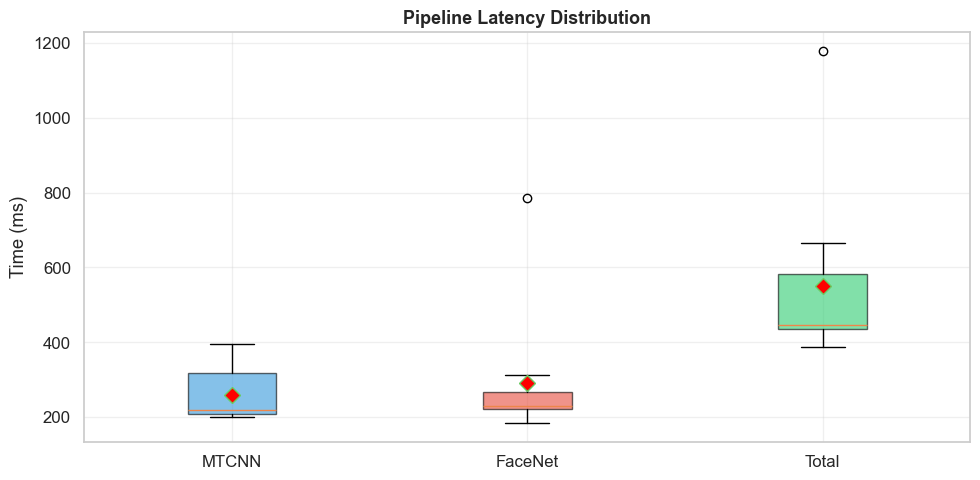


Latency (10 iterations):
  MTCNN:    259.7 +- 70.1 ms
  FaceNet:  290.0 +- 168.4 ms
  Total:    549.7 +- 226.8 ms


In [22]:
print('Benchmarking pipeline...')
N_ITER = 10
sample_img = None
for s in subject_dirs:
    for f in s.rglob('*.jpg'):
        sample_img = Image.open(str(f)); break
    if sample_img: break

if sample_img:
    mt, ft, tt = [], [], []
    for _ in range(N_ITER):
        t0 = time.perf_counter()
        face = mtcnn(sample_img)
        t1 = time.perf_counter()
        mt.append((t1-t0)*1000)
        if face is not None:
            face = face.unsqueeze(0).to(DEVICE)
            with torch.no_grad(): resnet(face)
        t2 = time.perf_counter()
        ft.append((t2-t1)*1000)
        tt.append((t2-t0)*1000)

    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot([mt, ft, tt], labels=['MTCNN', 'FaceNet', 'Total'],
                    patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
    for patch, c in zip(bp['boxes'], ['#3498db', '#e74c3c', '#2ecc71']):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_ylabel('Time (ms)')
    ax.set_title('Pipeline Latency Distribution', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'latency.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nLatency ({N_ITER} iterations):')
    print(f'  MTCNN:   {np.mean(mt):6.1f} +- {np.std(mt):.1f} ms')
    print(f'  FaceNet: {np.mean(ft):6.1f} +- {np.std(ft):.1f} ms')
    print(f'  Total:   {np.mean(tt):6.1f} +- {np.std(tt):.1f} ms')
else:
    print('No image for benchmark.')


---
## Ringkasan Hasil Eksperimen

In [23]:
print('='*70)
print('RINGKASAN HASIL EKSPERIMEN')
print('='*70)
print(f'\nDataset:')
print(f'  Subjek: {len(all_embeddings)}')
print(f'  Pose variations: {len(POSE_CONFIG)}')
print(f'\nPipeline Performance (Device: {DEVICE}):')
if sample_img:
    print(f'  MTCNN:   {np.mean(mt):.1f} ms')
    print(f'  FaceNet: {np.mean(ft):.1f} ms')
    print(f'  Total:   {np.mean(tt):.1f} ms')
if len(all_embeddings) >= 2 and 'best_tau' in dir():
    if len(y_scores) == len(y_true):
        yp_best = (y_scores >= best_tau).astype(int)
        tp = np.sum((yp_best==1)&(y_true==1))
        fp = np.sum((yp_best==1)&(y_true==0))
        fn = np.sum((yp_best==0)&(y_true==1))
        tn = np.sum((yp_best==0)&(y_true==0))
        acc = (tp+tn)/(tp+tn+fp+fn)*100
        far_best = fp/(fp+tn)*100 if (fp+tn)>0 else 0
        frr_best = fn/(fn+tp)*100 if (fn+tp)>0 else 0
        print(f'\nThreshold Analysis (tau={best_tau:.4f}):')
        print(f'  Accuracy:  {acc:.2f}%')
        print(f'  Optimal F1: {f1s[best_idx]:.4f} at tau={best_tau:.4f}')
        print(f'  FAR: {far_best:.2f}% | FRR: {frr_best:.2f}% | EER: {eer*100:.2f}% at tau={eer_tau:.4f}')
        print(f'  TP={tp} FP={fp} FN={fn} TN={tn}')
    else:
        print(f'\nThreshold Analysis (tau={best_tau:.4f}): Best F1={f1s[best_idx]:.4f}')

# Real-time test summary
if 'tester' in dir() and hasattr(tester, 'results') and len(tester.results) > 0:
    print(f'\nReal-time Test ({len(tester.results)} samples):')
    correct = sum(1 for r in tester.results if r['correct'])
    rt_acc = correct / len(tester.results) * 100
    print(f'  Correct:  {correct}/{len(tester.results)}')
    print(f'  Accuracy: {rt_acc:.2f}%')
    unknown = [r for r in tester.results if r['gt'] == '<unknown>']
    known = [r for r in tester.results if r['gt'] != '<unknown>']
    if unknown:
        fa = sum(1 for r in unknown if r['pred'] != '<unknown>')
        print(f'  FAR: {(fa/len(unknown))*100:.2f}% ({fa}/{len(unknown)} impostors accepted)')
    if known:
        fr = sum(1 for r in known if r['pred'] != r['gt'])
        print(f'  FRR: {(fr/len(known))*100:.2f}% ({fr}/{len(known)} genuine rejected)')

print(f'\nVisualizations saved:')
for f in sorted(DATA_DIR.glob('*.png')):
    print(f'  - {f.name}')
print('\n' + '='*70)
print('EKSPERIMEN SELESAI')
print('='*70)


RINGKASAN HASIL EKSPERIMEN

Dataset:
  Subjek: 3
  Pose variations: 8

Pipeline Performance (Device: cpu):
  MTCNN:   259.7 ms
  FaceNet: 290.0 ms
  Total:   549.7 ms

Threshold Analysis (tau=0.5388):
  Accuracy:  94.00%
  Optimal F1: 0.9434 at tau=0.5388
  FAR: 12.00% | FRR: 0.00% | EER: 8.00% at tau=0.5653
  TP=25 FP=3 FN=0 TN=22

Visualizations saved:
  - accuracy_per_pose.png
  - confusion_matrices.png
  - deteksi_rate.png
  - deteksi_wajah.png
  - face_alignment.png
  - latency.png
  - pca_space.png
  - realtime_cm.png
  - sample_embedding.png
  - similarity_dist.png
  - threshold_analysis.png
  - tsne_space.png

EKSPERIMEN SELESAI


---
## Referensi

1. Schroff et al. (2015). *FaceNet: A Unified Embedding for Face Recognition and Clustering*. CVPR.
2. Zhang et al. (2016). *Joint Face Detection and Alignment using Multi-task Cascaded Convolutional Networks*. IEEE SPL.
3. Szegedy et al. (2017). *Inception-v4, Inception-ResNet and the Impact of Residual Connections on Learning*. AAAI.
4. Malkov & Yashunin (2020). *Efficient and Robust Approximate Nearest Neighbor Search using HNSW*. IEEE TPAMI.

---
*Notebook eksperimen penelitian Computer Vision — Sistem Presensi Multi-Vector + Zero-Retraining*
